# Session 4 — Project Tasks

This notebook contains the data extraction, analysis, and visualization for Session 4 of the group project.

## Setup

Initialize database engine and load necessary libraries.

In [ ]:
import os
import pandas as pd
import numpy as np
import sqlalchemy as sa
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

url = sa.engine.URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASS"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", 31131)),
    database=os.getenv("DB_NAME", "linkedin_jobs"),
)

engine = sa.create_engine(url, connect_args={"ssl": {"check_hostname": False}})
print("Database engine created successfully.")

Database engine created successfully.


## Task 1 — Query with DuckDB: Postings by Industry

Load tables and find the number of full-time postings per industry name using DuckDB.

In [ ]:
df_job_industries = pd.read_sql("SELECT * FROM jobs_job_industries", engine)
df_industries = pd.read_sql("SELECT * FROM mappings_industries", engine)
df_postings_with_benefits = pd.read_sql("SELECT * FROM a20254350.postings_with_benefits", engine)
df_ft_postings = df_postings_with_benefits[df_postings_with_benefits['formatted_work_type'] == 'Full-time']

query_task1 = """
SELECT mi.industry_name, COUNT(p.job_id) AS posting_count
FROM df_postings_with_benefits p
JOIN df_job_industries ji ON p.job_id = ji.job_id
JOIN df_industries mi ON ji.industry_id = mi.industry_id
WHERE p.formatted_work_type = 'Full-time'
GROUP BY mi.industry_name
ORDER BY posting_count DESC
"""
df_industry_counts = duckdb.query(query_task1).to_df()
df_industry_counts.head(15)

,industry_name,posting_count
0,Hospitals and Health Care,4557
1,Financial Services,2394
2,Retail,2383
3,Staffing and Recruiting,2334
4,IT Services and IT Consulting,2063
5,Software Development,1113
6,Construction,940
7,Manufacturing,865
8,Banking,700
9,Telecommunications,656


**Why we used DuckDB instead of a Pandas merge:**

DuckDB allows us to write standard relational JOINs operations using SQL, which is cleaner and less verbose than nesting multiple Pandas merge operations.

## Task 2 — Analytics Challenge: Benefits by Industry

Filter to full-time postings where benefits contain 'Medical insurance' and show the top 10 industries.

In [8]:
query_task2 = f"""
SELECT mi.industry_name, COUNT(p.job_id) AS medical_insurance_count
FROM df_postings_with_benefits p
JOIN df_job_industries ji ON p.job_id = ji.job_id
JOIN df_industries mi ON ji.industry_id = mi.industry_id
WHERE p.formatted_work_type = 'Full-time'
AND p.benefits LIKE '%Medical insurance%'
GROUP BY mi.industry_name
ORDER BY medical_insurance_count DESC
LIMIT 10
"""
df_medical_benefits = duckdb.query(query_task2).to_df()
df_medical_benefits

,industry_name,medical_insurance_count
0,Hospitals and Health Care,235
1,Staffing and Recruiting,130
2,Financial Services,121
3,Construction,116
4,IT Services and IT Consulting,92
5,Manufacturing,91
6,Insurance,77
7,Defense and Space Manufacturing,75
8,Law Practice,71
9,Business Consulting and Services,71


**Does the industry ranking for medical insurance coverage match the overall posting ranking from Task 1, or are there industries that stand out?**

What stands out the most comparing both lists is the absence of the retail listings on medical insurance, not even making top 10, even though is the third on total postings by industry.

## Task 3 — Visualise Postings by Industry

Create a horizontal bar chart showing the top 15 industries by number of full-time postings.

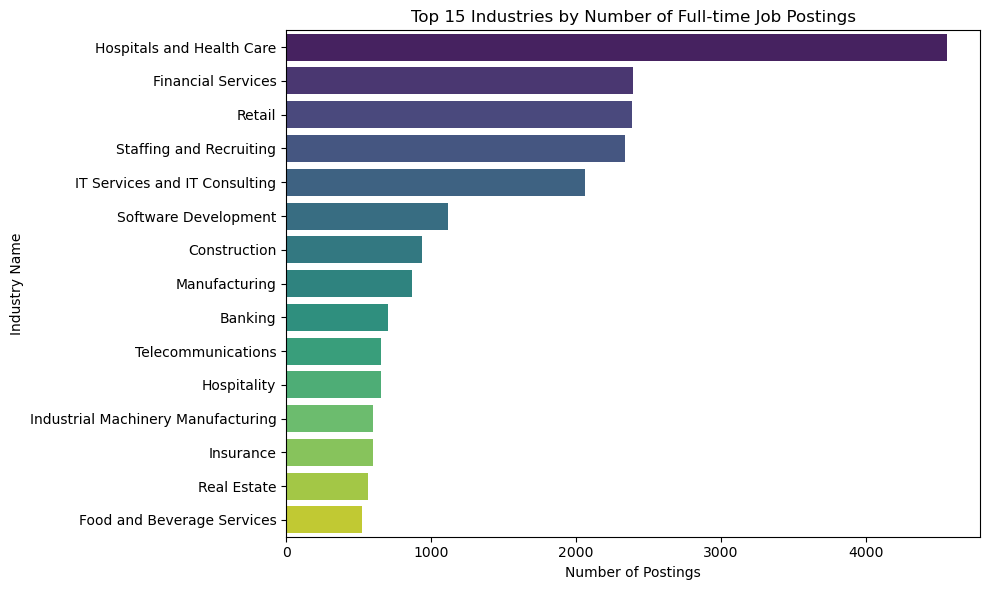

In [9]:
df_top15 = df_industry_counts.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='posting_count',
    y='industry_name',
    data=df_top15,
    hue='industry_name',
    palette='viridis',
    legend=False
)
plt.title('Top 15 Industries by Number of Full-time Job Postings')
plt.xlabel('Number of Postings')
plt.ylabel('Industry Name')
plt.tight_layout()
plt.show()

## Task 4 — Visualise the Distribution of Views

Create a histogram of the `views` column with a line indicating the median.

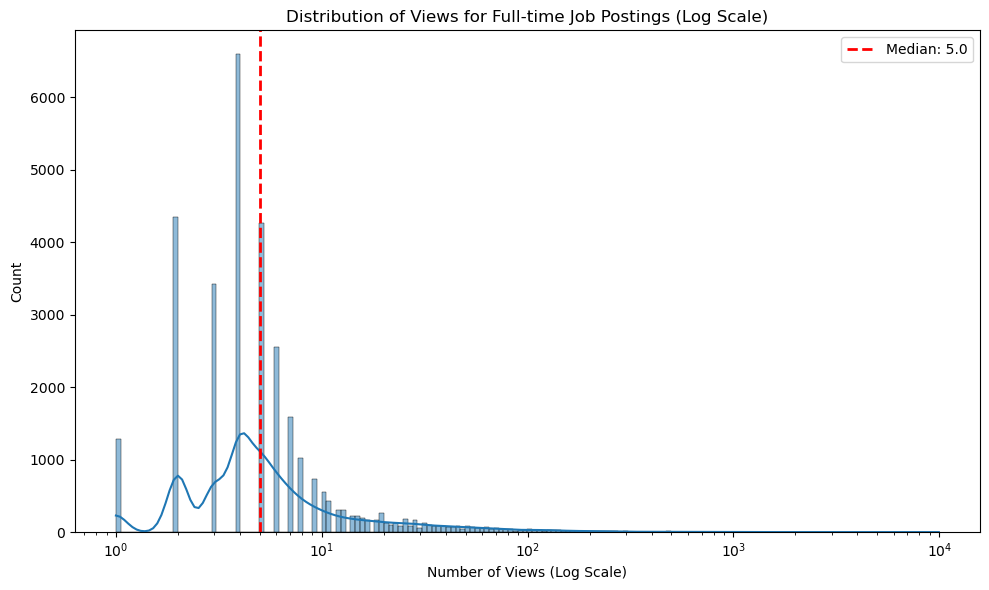

In [ ]:
plt.figure(figsize=(10, 6))

views_data = df_ft_postings['views'].dropna()
views_data = views_data[views_data > 0]

sns.histplot(views_data, log_scale=True, kde=True)
median_views = views_data.median()
plt.axvline(median_views, color='red', linestyle='--', linewidth=2, label=f'Median: {median_views}')

plt.title('Distribution of Views for Full-time Job Postings (Log Scale)')
plt.xlabel('Number of Views (Log Scale)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


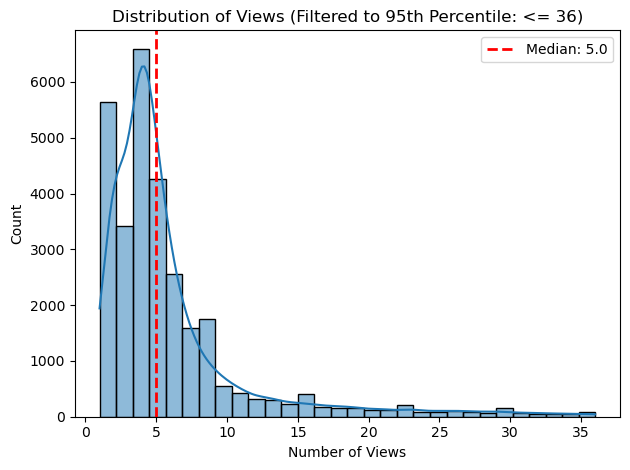

In [11]:

percentile_95 = views_data.quantile(0.95)
filtered_views = views_data[views_data <= percentile_95]
sns.histplot(filtered_views, bins=30, kde=True)
median_views = views_data.median()
plt.axvline(median_views, color='red', linestyle='--', linewidth=2, label=f'Median: {median_views}')
plt.title(f'Distribution of Views (Filtered to 95th Percentile: <= {percentile_95:.0f})')
plt.xlabel('Number of Views')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Does the distribution look symmetric, or is it skewed?**

The distribution is highly skewed, with a vast majority of job postings having low view counts and a long tail extending to a few postings with exceptionally high engagement.

## Task 5 — Save Your Results

Save the outputs to CSV and JSON files in the `output/` directory.

In [ ]:
import json
os.makedirs('output', exist_ok=True)
df_industry_counts.to_csv('output/industry_posting_counts.csv', index=False)
print("Saved industry_posting_counts.csv successfully.")

session3_top10_countries = {
    "top_countries": [
        {"country": "US", "count": 21635},
        {"country": "0", "count": 727},
        {"country": "GB", "count": 620},
        {"country": "CA", "count": 258},
        {"country": "IN", "count": 157},
        {"country": "DE", "count": 128},
        {"country": "FR", "count": 118},
        {"country": "CH", "count": 93},
        {"country": "AU", "count": 73},
        {"country": "NL", "count": 64}
    ]
}

with open('output/top_countries.json', 'w') as f:
    json.dump(session3_top10_countries, f, indent=4)
print("Saved top_countries.json successfully.")

Saved industry_posting_counts.csv successfully.
Saved top_countries.json successfully.


## Task 6 — Verify Python Module (analysis.py)

Import and run all four functions from `analysis.py` to confirm they produce the same results.

In [ ]:
from analysis import load_postings, filter_fulltime, company_summary, top_industries

df_postings_loaded = load_postings(engine)
df_ft_loaded = filter_fulltime(df_postings_loaded)
df_companies_us = company_summary(engine)
df_top_industries = top_industries(df_ft_loaded, df_job_industries, df_industries, 15)

print(f"load_postings loaded: {len(df_postings_loaded)} rows")
print(f"filter_fulltime returned: {len(df_ft_loaded)} rows")
print(f"company_summary returned: {len(df_companies_us)} US companies")
print(f"top_industries shape: {df_top_industries.shape}")

load_postings loaded: 39361 rows
filter_fulltime returned: 31791 rows
company_summary returned: 21635 US companies
top_industries shape: (15, 2)
